# Multi linear Regression

***More than one input decides the output***

In [72]:
import pandas as pd

In [73]:
data = pd.read_csv("Student_Performance.csv")

In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [75]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [76]:
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [77]:
# preprocessing : he process of cleaning and transforming raw data into a format that a machine-learning model can understand and learn from effectively
# Feature Engineering : Normalization , standardization, encoding, modify
# Feature selection : selecting imp columns 

Encoding

In [78]:
data["Extracurricular Activities"].unique()

array(['Yes', 'No'], dtype=object)

In [79]:
data["Extracurricular Activities"] = data["Extracurricular Activities"].replace(["Yes", "No"], [1,0])

C:\Users\sahil\AppData\Local\Temp\ipykernel_15124\1085222340.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Extracurricular Activities"] = data["Extracurricular Activities"].replace(["Yes", "No"], [1,0])


In [80]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [81]:
corr = data.corr()*100
corr

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,100.000000,-1.238992,0.387254,0.124520,1.746317,37.373035
Previous Scores,-1.238992,100.000000,0.836932,0.594422,0.788803,91.518914
Extracurricular Activities,0.387254,0.836932,100.000000,-2.328364,1.310278,2.452495
Sleep Hours,0.124520,0.594422,-2.328364,100.000000,0.399022,4.810584
Sample Question Papers Practiced,1.746317,0.788803,1.310278,0.399022,100.000000,4.326833
Performance Index,37.373035,91.518914,2.452495,4.810584,4.326833,100.000000


In [82]:
# Understanding using Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

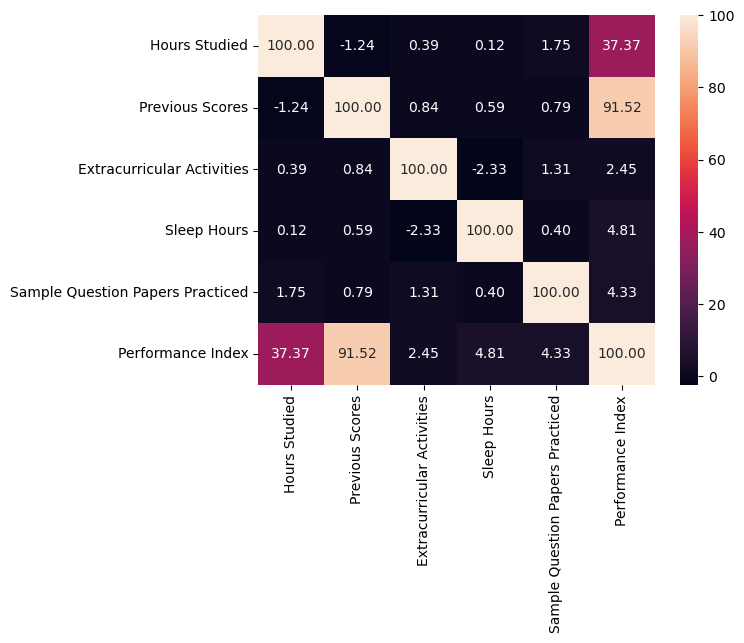

In [83]:
plt.plot(figsize= (12,8))
sns.heatmap(corr, annot=True, fmt = "0.2f")

In [84]:
x = data.iloc[: ,:-1]

In [85]:
x.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5


In [86]:
type(x)

pandas.core.frame.DataFrame

In [87]:
y = data["Performance Index"]

In [88]:
y.head()

0    91.0
1    65.0
2    45.0
3    36.0
4    66.0
Name: Performance Index, dtype: float64

In [89]:
type(y)

pandas.core.series.Series

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [91]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state= 42)

In [109]:
x_train.shape

(8000, 5)

In [ ]:
x_test.shape

(2000, 5)

In [112]:
y_train.shape

(8000,)

In [94]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [95]:
y_pred = model.predict(x_test)

In [96]:
y_pred_train = model.predict(x_train)

In [97]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [98]:
r2_score(y_test,y_pred)*100

98.89832909573146

In [99]:
r2_score(y_train,y_pred_train)*100

98.86898790682355

In [100]:
mean_squared_error(y_test,y_pred)

4.082628398521852

In [101]:
mean_squared_error(y_train,y_pred_train)


4.169735849525008

In [102]:
mean_absolute_error(y_test,y_pred)

1.611121346312304

In [103]:
mean_absolute_error(y_train, y_pred_train)

1.6193054830334268

In [113]:
# y = m1x1 + m2x2 + m3x3 + m4x4 + m5x5 + c
model.coef_

array([2.85248393, 1.0169882 , 0.60861668, 0.47694148, 0.19183144])

In [114]:
model.intercept_

np.float64(-33.921946215556424)

In [115]:
model.predict([[7,78,1,6,4]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([69.60811216])

In [118]:
# using The Formula
2.85248393*7 + 1.0169882*78 + 0.60861668*1 + 0.47694148*6 + 0.19183144*4 + (-33.921946215556424)

69.60811221444357

In [119]:
import joblib

In [120]:
joblib.dump(model,"MLR.joblib")

['MLR.joblib']